# 00_main 

Orchestrates the full thesis experiment: runs four LLM-based text-to-SQL architectures (SAS → SAS\_RAG → MAS\_RAG → Dynamic Filtered MAS\_RAG) across 25 evaluation questions, repeated 3 times to quantify LLM non-determinism. Each repetition persists results to Delta; downstream cells compute mean ± std for every KPI and export thesis-ready figures.

## Execution Flow
```
1. Load shared modules (mt_config → mt_logging [inlined] → mt_evaluation → mt_evaluation_questions → mt_context_builder → mt_retrieval)
2. For each repetition (1–3):
     %run ./01_Single_Agent_System_SAS        → 25 questions → capture results
     %run ./02_RAG_Single_Agent               → 25 questions → capture results
     %run ./03_MAS_RAG                        → 25 questions → capture results
     %run ./04_Dynamic_Filtered_MAS_RAG       → 25 questions → capture results
3. Combine all 300 runs → persist to Delta
4. Restore from Delta (enables analysis without re-running)
5. Per-repetition summary + averaged comparison (mean ± std)
6. Thesis figures and PDF exports
```

## Architectures
| Architecture | Agents | Semantic Delivery | Key Mechanism |
|---|---|---|---|
| `SAS` | 1 | Direct (full ~7K chars in prompt) | Baseline: plan → SQL → interpret |
| `SAS_RAG` | 1 | Retrieved (top-5 chunks) | Same agent + vector retrieval step |
| `MAS_RAG` | 5 (static) | Retrieved (top-5 chunks) | All 5 experts always run sequentially |
| `DYNAMIC_FILTERED_MAS_RAG` | 2–5 (adaptive) | Retrieved + filtered | FFN gating, adaptive budget, communication pruning, early stopping |

## Shared Modules
| Module | What it provides |
|---|---|
| `mt_config` | Model endpoint, LLM params, agent profiles, architecture registry |
| `mt_context_builder` | Loads technical schema + join map from `mt_information_schema`; for SAS also injects full semantic layer |
| `mt_retrieval` | Builds vector store (53 chunks from 5 semantic tables); provides `retrieve_semantic_context(question)` |
| `mt_evaluation` | Claim-level metrics: precision, recall, F1, groundedness, hallucination risk |
| `mt_evaluation_questions` | 25 questions (Q1–Q25) with expected answers, difficulty, claims |
| `mt_logging` | Delta table write for experiment results *(inlined — not loaded via %run)* |

In [0]:
%run ./mt_config

✓ mt_config | dev_forge_default.mt_davide | databricks-meta-llama-3-1-8b-instruct
  Mode: 🟢 LIVE


✓ AGENT_PROFILES defined: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  MAS static order: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR


In [0]:
# ============================================================
# mt_logging — inlined (workaround for %run failure on serverless)
# ============================================================
import logging

# --- Suppress verbose SQL error logging ---
logging.getLogger("SQLQueryContextLogger").setLevel(logging.WARNING)
logging.getLogger("py4j").setLevel(logging.WARNING)
logging.getLogger("py4j.java_gateway").setLevel(logging.WARNING)

# Logger._log patch SKIPPED on serverless — only needed on DBR 16.4 dedicated cluster.
# The errorClass kwarg issue does not occur on serverless runtime.

# --- v3 Logging tables ---
V3_RUNS_TABLE = f"{MT_CATALOG}.{MT_SCHEMA}.experiment_runs_v3"
V3_STEPS_TABLE = f"{MT_CATALOG}.{MT_SCHEMA}.agent_steps_v3"
V3_EVAL_TABLE = f"{MT_CATALOG}.{MT_SCHEMA}.evaluation_results_v3"
V3_RETRIEVAL_TABLE = f"{MT_CATALOG}.{MT_SCHEMA}.retrieval_results_v3"

def ensure_v3_tables():
    spark.sql(f"""CREATE TABLE IF NOT EXISTS {V3_RUNS_TABLE} (
        run_id STRING, timestamp STRING, question_id STRING, question_text STRING,
        question_type STRING, difficulty STRING, architecture STRING, context_mode STRING,
        semantic_delivery STRING, profile_name STRING, model STRING, configuration_id STRING,
        repetition INT, status STRING, final_answer STRING, started_at TIMESTAMP,
        completed_at TIMESTAMP, total_latency_ms DOUBLE
    ) USING DELTA""")
    spark.sql(f"""CREATE TABLE IF NOT EXISTS {V3_STEPS_TABLE} (
        run_id STRING, step_number INT, agent_name STRING, action STRING, status STRING,
        latency_ms DOUBLE, input_tokens INT, output_tokens INT, sql_attempt INT, error_type STRING
    ) USING DELTA""")
    spark.sql(f"""CREATE TABLE IF NOT EXISTS {V3_EVAL_TABLE} (
        run_id STRING, answer_correctness DOUBLE, numerical_accuracy DOUBLE,
        groundedness_score DOUBLE, completeness_score DOUBLE, sql_execution_success BOOLEAN,
        hallucination_detected BOOLEAN, reviewer_decision STRING, reviewer_changed_answer BOOLEAN,
        total_input_tokens INT, total_output_tokens INT, total_tokens INT,
        total_latency_ms DOUBLE, estimated_cost_usd DOUBLE, llm_calls INT,
        sql_attempts INT, semantic_objects_retrieved INT
    ) USING DELTA""")
    spark.sql(f"""CREATE TABLE IF NOT EXISTS {V3_RETRIEVAL_TABLE} (
        run_id STRING, rank INT, semantic_object_id STRING,
        semantic_object_type STRING, similarity_score DOUBLE
    ) USING DELTA""")

def log_run_v3(run_data: dict) -> str:
    import uuid as _uuid
    from datetime import datetime as _dt
    run_id = run_data.get("run_id") or str(_uuid.uuid4())
    row = {"run_id": run_id, "timestamp": run_data.get("timestamp", _dt.utcnow().isoformat()),
           "question_id": run_data.get("question_id", ""), "question_text": run_data.get("question_text", ""),
           "question_type": run_data.get("question_type", ""), "difficulty": run_data.get("difficulty", ""),
           "architecture": run_data.get("architecture", ""), "context_mode": run_data.get("context_mode", "UNIFIED"),
           "semantic_delivery": run_data.get("semantic_delivery", ""),
           "profile_name": run_data.get("profile_name", "Enterprise Data Analyst"),
           "model": run_data.get("model", MT_MODEL_ENDPOINT),
           "configuration_id": run_data.get("configuration_id"), "repetition": run_data.get("repetition", 1),
           "status": run_data.get("status", "success"), "final_answer": run_data.get("final_answer"),
           "started_at": run_data.get("started_at"), "completed_at": run_data.get("completed_at"),
           "total_latency_ms": run_data.get("total_latency_ms")}
    spark.createDataFrame([row]).write.format("delta").mode("append").saveAsTable(V3_RUNS_TABLE)
    return run_id

def log_step_v3(step_data: dict):
    row = {"run_id": step_data.get("run_id"), "step_number": step_data.get("step_number", 0),
           "agent_name": step_data.get("agent_name", ""), "action": step_data.get("action", ""),
           "status": step_data.get("status", "success"), "latency_ms": step_data.get("latency_ms"),
           "input_tokens": step_data.get("input_tokens"), "output_tokens": step_data.get("output_tokens"),
           "sql_attempt": step_data.get("sql_attempt"), "error_type": step_data.get("error_type")}
    spark.createDataFrame([row]).write.format("delta").mode("append").saveAsTable(V3_STEPS_TABLE)

def log_evaluation_v3(eval_data: dict):
    row = {"run_id": eval_data.get("run_id"), "answer_correctness": eval_data.get("answer_correctness"),
           "numerical_accuracy": eval_data.get("numerical_accuracy"),
           "groundedness_score": eval_data.get("groundedness_score"),
           "completeness_score": eval_data.get("completeness_score"),
           "sql_execution_success": eval_data.get("sql_execution_success"),
           "hallucination_detected": eval_data.get("hallucination_detected"),
           "reviewer_decision": eval_data.get("reviewer_decision"),
           "reviewer_changed_answer": eval_data.get("reviewer_changed_answer"),
           "total_input_tokens": eval_data.get("total_input_tokens"),
           "total_output_tokens": eval_data.get("total_output_tokens"),
           "total_tokens": eval_data.get("total_tokens"),
           "total_latency_ms": eval_data.get("total_latency_ms"),
           "estimated_cost_usd": eval_data.get("estimated_cost_usd"),
           "llm_calls": eval_data.get("llm_calls"), "sql_attempts": eval_data.get("sql_attempts"),
           "semantic_objects_retrieved": eval_data.get("semantic_objects_retrieved")}
    spark.createDataFrame([row]).write.format("delta").mode("append").saveAsTable(V3_EVAL_TABLE)

def log_retrieval_v3(run_id: str, retrievals: list):
    if not retrievals: return
    rows = [{"run_id": run_id, "rank": r.get("rank"), "semantic_object_id": r.get("semantic_object_id"),
             "semantic_object_type": r.get("semantic_object_type"), "similarity_score": r.get("similarity_score")}
            for r in retrievals]
    spark.createDataFrame(rows).write.format("delta").mode("append").saveAsTable(V3_RETRIEVAL_TABLE)

# Tables already exist — skip ensure_v3_tables() to avoid kernel crash on serverless
print("\u2713 Verbose SQL error logging suppressed (SQLQueryContextLogger \u2192 WARNING)")
print("\u2713 Logger._log patch skipped (serverless runtime does not need it)")
print("\u2713 v3 logging functions defined (tables pre-exist)")

✓ Verbose SQL error logging suppressed (SQLQueryContextLogger → WARNING)
✓ Logger._log patch skipped (serverless runtime does not need it)
✓ v3 logging functions defined (tables pre-exist)


In [0]:
%run ./mt_evaluation

✓ mt_evaluation helper functions loaded


✓ Claim extraction & normalisation loaded


✓ Claim matching & entailment loaded


✓ Claim correctness, groundedness & compute_all_metrics() v3 loaded
  Thesis KPIs: claim_precision, claim_recall, claim_f1, claim_TP/FP/FN
  Thesis KPIs: groundedness, hallucination_rate (claim-based)
  Thesis KPIs: answer_correct, answered, abstained, sql_execution_success
  Thesis KPIs: post_failure_fabrication, sql_semantically_correct


In [0]:
%run ./mt_evaluation_questions

Loaded 10 evaluation questions

Difficulty distribution:
  easy: 2
  medium: 3
  hard: 3
  very_hard: 2

Questions:
  Q1 [easy] basic_aggregation: How many total certificates were earned in February 2026?...
  Q2 [easy] temporal_aggregation: How many distinct users earned at least one certificate per month in Q...
  Q3 [medium] ranking: Which 5 companies earned the most certificates in 2026? Show the compa...
  Q4 [medium] trend_comparison: Compare mandatory vs elective certificate completion trends month-over...
  Q5 [medium] segmented_metric: What is the on-time completion rate for mandatory courses (Pflichtkurs...
  Q6 [hard] multi_metric_correlation: Which 5 active companies have the highest certificate volumes in 2026?...
  Q7 [hard] derived_metric_trend: How has the on-time completion rate changed month-over-month in H1 202...
  Q8 [hard] churn_analysis: For companies with INACTIVE status, what was their average on-time com...
  Q9 [very_hard] temporal_pattern_detection: Identify


EXTENDED EVALUATION SET: 25 total questions

Difficulty distribution:
  easy: 5
  medium: 8
  hard: 7
  very_hard: 5

Unanswerable (hallucination tests): 5
Answerable: 20

New questions:
  Q11 [easy] basic_count → MAS_weakness: How many companies are currently in ACTIVE status? How does ...
  Q12 [easy] unanswerable_financial [UNANSWERABLE] → hallucination_test: What was the average monthly revenue per user in Q1 2026? Br...
  Q13 [easy] basic_aggregation → MAS_weakness: How many distinct courses exist in the platform? What is the...
  Q14 [medium] sorting_filtering → RAG_weakness: Which companies created their account most recently (in 2026...
  Q15 [medium] unanswerable_geographic [UNANSWERABLE] → hallucination_test: What is the geographic distribution of companies by country ...
  Q16 [medium] conditional_aggregation → SAS_weakness: What percentage of assignments with a deadline were complete...
  Q17 [medium] multi_table_join → SAS_weakness: For each company size category, what is

✓ Expected claims loaded: 20/25 questions have ground-truth claims
  Q6, Q8, Q9, Q10 require prepare_expected_claims() or manual review


In [0]:
%run ./mt_context_builder

✓ mt_context_builder helpers loaded
  Tables: 10


✓ mt_context_builder loaded (UNIFIED mode)
  build_unified_context(architecture)        — SAS=direct, RAG=retrieved
  format_unified_context_for_prompt(ctx)    — LLM-ready prompt string
  get_semantic_retrieval_source()           — semantic content for RAG indexing


In [0]:
%run ./mt_retrieval

mt_retrieval: embedding_model=databricks-gte-large-en, top_k=5, threshold=0.3


✓ Embedding client ready


✓ Chunk builder defined


✓ SemanticVectorStore class defined


✓ Public API ready: retrieve_semantic_context(), format_retrieved_context_for_prompt(), get_retrieval_log()


Building semantic vector store...
  ✓ Vector store built: 53 chunks, 1024-dim embeddings, 28.4s
    business_rule: 14
    column_metadata: 8
    join_rule: 10
    metric_definition: 11
    table_metadata: 10

✓ mt_retrieval loaded and ready
  retrieve_semantic_context(question) → top-5 chunks (threshold=0.3)
  format_retrieved_context_for_prompt(chunks) → prompt string
  get_retrieval_log(chunks) → logging-friendly list


[Trace(trace_id=tr-4eb814ecb2a2cecf68f7853b8e017df3), Trace(trace_id=tr-fabfa45a9e60b0224ab62f2e89d0bc9d), Trace(trace_id=tr-ca43770561eb719e028e70df1a4607a5), Trace(trace_id=tr-e42f57a9a5c6c783654f2a6ce14f0d9c)]

In [0]:
# ============================================================
# 3-REPETITION EXPERIMENT CONFIGURATION
# ============================================================
EXPERIMENT_SEED = 42
QUESTION_FILTER = None   # All 25 questions
ARCHITECTURES_TO_RUN = []  # Empty — architecture capture cells won't persist to Delta individually
_QUIET = True
_RESULTS_TABLE = "dev_forge_default.mt_davide.experiment_thesis_results"
all_experiment_results = []

N_REPS = 3
_all_results = []       # Collects DataFrames from every architecture × rep
_capture_count = 0

def _capture_rep(rep_num):
    """Capture current results_df with repetition marker."""
    global _capture_count
    _df = results_df.copy()
    _df['repetition'] = rep_num
    _all_results.append(_df)
    _capture_count += 1
    arch = _df['architecture'].iloc[0] if 'architecture' in _df.columns else 'unknown'
    n = len(_df)
    total = N_REPS * 4  # 4 architectures × 3 reps
    print(f"\u2713 [{_capture_count}/{total}] {arch} rep {rep_num}: {n} runs captured")

def _print_cumulative_comparison():
    pass  # no-op for 3-rep experiment

print(f"={'='*70}")
print(f"3-REPETITION EXPERIMENT")
print(f"={'='*70}")
print(f"  Repetitions:    {N_REPS}")
print(f"  Architectures:  SAS, SAS_RAG, MAS_RAG, DYNAMIC_FILTERED_MAS_RAG")
print(f"  Questions:      {'ALL 25' if QUESTION_FILTER is None else QUESTION_FILTER}")
print(f"  Total runs:     {N_REPS} × 4 × 25 = 300")
print(f"  Results table:  {_RESULTS_TABLE}")
print(f"={'='*70}")

3-REPETITION EXPERIMENT
  Repetitions:    3
  Architectures:  SAS, SAS_RAG, MAS_RAG, DYNAMIC_FILTERED_MAS_RAG
  Questions:      ALL 25
  Total runs:     3 × 4 × 25 = 300
  Results table:  dev_forge_default.mt_davide.experiment_thesis_results


In [0]:
%run ./01_Single_Agent_System_SAS

SAS configured | databricks-meta-llama-3-1-8b-instruct | context: 28,038 chars


✓ run_sas() defined | Workflow: Plan → SQL → Execute → Interpret (3 LLM calls)


SAS: 25 questions | direct semantic | databricks-meta-llama-3-1-8b-instruct
  Q1: 2.8s | 7164 tok | SQL:not_applicable


{"ts": "2026-09-18 09:05:50.550", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[AMBIGUOUS_REFERENCE] Reference `id` is ambiguous, could be: [`dev_forge_default`.`mt_davide`.`mt_safe_certificate`.`id`, `dev_forge_default`.`mt_davide`.`mt_safe_user`.`id`]. SQLSTATE: 42704; line 6 pos 74\n\nJVM stacktrace:\norg.apache.spark.sql.AnalysisException\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.ambiguousReferenceError(QueryCompilationErrors.scala:3309)\n\tat org.apache.spark.sql.catalyst.expressions.package$AttributeSeq.resolve(package.scala:372)\n\tat org.apache.spark.sql.catalyst.plans.logical.LogicalPlan.resolveChildren(LogicalPlan.scala:257)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpressionByPlanChildren$1(ColumnResolutionHelper.scala:488)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpression$3(ColumnResolutionHelper.scala:155)\n\tat org.apache.spark.sql.catalyst.analysis.pack

  Q2: 6.1s | 20191 tok | SQL:failed
  Q3: 19.5s | 15118 tok | SQL:success
  Q4: 8.7s | 16025 tok | SQL:success
  Q5: 11.1s | 15693 tok | SQL:success
  Q6: 7.3s | 15900 tok | SQL:success
  Q7: 7.5s | 17586 tok | SQL:failed


...

  Q24: 4.9s | 19098 tok | SQL:failed


{"ts": "2026-09-18 09:12:15.338", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[TABLE_OR_VIEW_NOT_FOUND] The table or view `mt_safe_exam_result` cannot be found. Verify the spelling and correctness of the schema and catalog.\nIf you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.\nTo tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS. SQLSTATE: 42P01; line 8 pos 6;\n'Project ['company_ID, 'failure_rate, 'overall_average, 'threshold]\n+- 'SubqueryAlias anomalous_companies\n   +- 'SubqueryAlias anomalous_companies\n      +- 'Project ['company_ID, 'failure_rate, 'overall_average, ('overall_average + (2 * 'STDDEV('failure_rate))) AS threshold#5061]\n         +- 'Filter ('failure_rate > ('overall_average + (2 * 'STDDEV('failure_rate))))\n            +- 'Join Cross\n               :- 'SubqueryAlias company_failure_rates\n               :  +- 'SubqueryAlias company_fail

  Q25: 5.6s | 19946 tok | SQL:failed
✓ SAS complete: 25 runs | Avg latency: 6.8s


[Trace(trace_id=tr-8b6bad581ce7e842a3fbd7049af833a8), Trace(trace_id=tr-4ee24877fbad429f356e51ec88960869), Trace(trace_id=tr-a58a8dbe37b7bf5ec4b50b4cc8925ced), Trace(trace_id=tr-f1466fe5b14ba099e08fc38b5f1a3269), Trace(trace_id=tr-8f3764510805c28c3f5f10cd0705f4ff), Trace(trace_id=tr-085cb244f631bdc9b82e46f871fea72f), Trace(trace_id=tr-27ae8f969dff0cf4830c69bc4312a7fd), Trace(trace_id=tr-52baf62da32854d17d3aab56df8c4565), Trace(trace_id=tr-b43f4e19e8be5ab93959a8a9bb91d859), Trace(trace_id=tr-79f12aa966158a73b1130dd755a5127c)]

⚠ SAS not run or no results


In [0]:
_capture_rep(1)

✓ [1/12] SAS rep 1: 25 runs captured


In [0]:
%run ./02_RAG_Single_Agent

✓ SAS_RAG configured
  Model:           databricks-meta-llama-3-1-8b-instruct
  Architecture:    SAS_RAG
  Semantic:        retrieved (top-5)
  Base context:    12,491 chars (technical only)


✓ run_sas_rag() defined
  Workflow: Retrieve → Plan (LLM#1) → SQL (LLM#2) → Execute → Interpret (LLM#3)
  LLM calls per question: 3 + retrieval


SAS_RAG: 25 questions | top-5 retrieval | databricks-meta-llama-3-1-8b-instruct
  Q1: 5.5s | 9254 tok | SQL:success | chunks:5
  Q2: 7.0s | 9702 tok | SQL:success | chunks:5


{"ts": "2026-09-18 09:13:07.354", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID` cannot be resolved. Did you mean one of the following? [`u`.`day`, `u`.`ass_id`, `c`.`completedOn`, `c`.`courseId`, `c`.`id`]. SQLSTATE: 42703; line 2 pos 2;\n'GlobalLimit 5\n+- 'LocalLimit 5\n   +- 'Sort ['total_certificates DESC NULLS LAST], true\n      +- 'Aggregate ['c.company_ID], ['c.company_ID, count(1) AS total_certificates#5554L]\n         +- Filter (year#5595 = 2026)\n            +- Join Inner, (id#5599 = id#5625)\n               :- SubqueryAlias u\n               :  +- SubqueryAlias dev_forge_default.mt_davide.mt_safe_user\n               :     +- Relation dev_forge_default.mt_davide.mt_safe_user[user_id#5593,course_id#5594,year#5595,user_course_state#5596,assignment_id1#5597,course_type#5598,id#5599,courseId#5600,u_id#5601,ass_id#5602,completedOn#5603,certificate_type#5604,Nr_C

  Q3: 5.2s | 12495 tok | SQL:failed | chunks:5
  Q4: 6.1s | 9863 tok | SQL:success | chunks:5


...

{"ts": "2026-09-18 09:19:33.907", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `overall_average_failure_rate` cannot be resolved. Did you mean one of the following? [`failed_exams`, `total_exams`, `company_id`]. SQLSTATE: 42703; line 27 pos 6;\n'WithCTE\n:- CTERelationDef 48, false\n:  +- SubqueryAlias overall_average_failure_rate\n:     +- Aggregate [avg((cast(failed_exams#8244L as double) / cast(total_exams#8243L as double))) AS overall_average_failure_rate#8245]\n:        +- SubqueryAlias company_failure_rate\n:           +- CTERelationRef 47, true, [company_id#8242, total_exams#8243L, failed_exams#8244L], false, false\n+- 'Project ['company_id, ('failed_exams / 'total_exams) AS failure_rate#8240, 'overall_average_failure_rate, 'threshold]\n   +- 'Filter ((cast(failed_exams#8271L as double) / cast(total_exams#8270L as double)) > scalar-subquery#8241 [])\n      :  +- 'Project ['thr

  Q25: 6.0s | 13971 tok | SQL:failed | chunks:5

SAS_RAG RUN COMPLETE: 25 runs
  SQL success:     8/25
  Avg latency:     6.17s
  Total tokens:    299,165
  Avg correctness: 0.32
  Avg groundedness:0.48


[Trace(trace_id=tr-58b0d024050aff05ae5ac59c35120234), Trace(trace_id=tr-6cd6b47111637c5239e1888849a84c6d), Trace(trace_id=tr-b684e6466f9777c9fb841847e3e0f2c4), Trace(trace_id=tr-ac8d2ff106ad9e0380494ffa93e45935), Trace(trace_id=tr-a640775b047a47a71f90d6afa34b940a), Trace(trace_id=tr-e714f13637a290eaf439f7dc18b647d2), Trace(trace_id=tr-e7dfa19741716d8e7b5e1c2354be24a6), Trace(trace_id=tr-3a8cee6c6ce28680ef4e58f72d69756a), Trace(trace_id=tr-6fabcc81db4102d2985ce0d2a1dc81e9), Trace(trace_id=tr-4c37d8b2b11d5500451714b4ce89965b)]

⚠ SAS_RAG not run or no results


1050

In [0]:
_capture_rep(1)

✓ [2/12] SAS_RAG rep 1: 25 runs captured


In [0]:
%run ./03_MAS_RAG

✓ MAS_RAG configured (MAS_RAG)
  Agents: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  Model:  databricks-meta-llama-3-1-8b-instruct
  Schema context: 12,491 chars


✓ Agent pipeline defined
  run_agent(state, agent_name) — runs one expert
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR


✓ run_mas_rag() defined
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR
  Static: all 5 agents participate on every question
  Retry: SQL_DEVELOPER retries up to 2 attempts on failure
  Termination: CANNOT_ANSWER (pre-QA agents) → early abstain; QA uses startswith only


MAS_RAG: 25 questions | 5 expert agents | databricks-meta-llama-3-1-8b-instruct
  Q1: 10.9s | 25710 tok | SQL:success | agents:5 calls
  Q2: 11.8s | 26548 tok | SQL:success | agents:5 calls


{"ts": "2026-09-18 09:20:45.255", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID` cannot be resolved. Did you mean one of the following? [`co`.`company_ID`, `a`.`company_ID1`, `co`.`company_Name`, `co`.`company_Status`, `c`.`completedOn`]. SQLSTATE: 42703; line 3 pos 4;\n'GlobalLimit 5\n+- 'LocalLimit 5\n   +- 'Sort ['total_certificate_count DESC NULLS LAST], true\n      +- 'Project ['company_ID, 'total_certificate_count]\n         +- 'SubqueryAlias certificate_counts\n            +- 'SubqueryAlias certificate_counts\n               +- 'Aggregate [company_ID#8849], ['c.company_ID AS company_ID#8805, count(1) AS total_certificate_count#8806L]\n                  +- Filter (extract(YEAR, completedOn#8817) = 2026)\n                     +- Join Inner, (company_ID1#8841 = company_ID#8849)\n                        :- Join Inner, (assignmentId#8816 = assignment_ID#8840)\n      

...

{"ts": "2026-09-18 09:30:56.853", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[INVALID_WHERE_CONDITION] The WHERE condition \"(failure_rate > (overall_failure_rate + (2 * stddev(failure_rate))))\" contains invalid expressions: stddev(company_failure_rates.failure_rate).\nRewrite the query to avoid window functions, aggregate functions, and generator functions in the WHERE clause. SQLSTATE: 42903; line 26 pos 4;\nGlobalLimit 100\n+- LocalLimit 100\n   +- Project [company_ID#15608, failure_rate#15609, overall_failure_rate#15479, threshold#15480]\n      +- SubqueryAlias anomalous_companies\n         +- SubqueryAlias anomalous_companies\n            +- Aggregate [company_ID#15608, failure_rate#15609, overall_failure_rate#15479, (cast(2 as double) * stddev(failure_rate#15609)) AS threshold#15480]\n               +- Filter (failure_rate#15609 > (overall_failure_rate#15479 + (cast(2 as double) * stddev(failure_rate#15609))))\n                  +- Join Cross\n                 

  Q25: 18.3s | 37068 tok | SQL:success | agents:6 calls

MAS_RAG RUN COMPLETE: 25 runs
  SQL success:     12/25
  Avg latency:     14.67s
  Total tokens:    1,004,201
  Avg correctness: 0.40
  Avg groundedness:0.45


[Trace(trace_id=tr-23d53d4218414cf4deafa9d7aefbd86d), Trace(trace_id=tr-3145dc576917d33045d4de14ea326fe6), Trace(trace_id=tr-cb9b397779ef21a8ed7d4389f487d4cc), Trace(trace_id=tr-538213f4eab532f0cbf8a435a58548be), Trace(trace_id=tr-56c6776d0c58b0418f942f6260ba1a1e), Trace(trace_id=tr-8dadf22a6f0c46ceab3a6bfc471a11b9), Trace(trace_id=tr-4d864f1a0ef9dce7a7843ebb751d35fc), Trace(trace_id=tr-578473d5a9621ba19936621c0bf8d711), Trace(trace_id=tr-18811cc5a37d41799f914e428563b1e0), Trace(trace_id=tr-9dc7e77373904981bc7f9626bfd72b40)]

⚠ MAS_RAG not run or no results


2016

In [0]:
_capture_rep(1)

✓ [3/12] MAS_RAG rep 1: 25 runs captured


In [0]:
%run ./04_Dynamic_Filtered_MAS_RAG

✓ DYNAMIC_FILTERED_MAS_RAG configured
  Expert pool: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  FFN gating: full>=0.6, compressed>=0.3, skipped<0.3
  Mandatory agents (always full): SQL_DEVELOPER, QUALITY_AUDITOR
  Model: databricks-meta-llama-3-1-8b-instruct
  Evidence filter: relevance>0.35, dedup>0.92
  Adaptive budget (sim-based): sim>=0.61→500tok/2ch | >=0.58→900/3 | >=0.55→1200/4 | <0.55→1500/5


✓ Evidence filtering & structured communication defined
  Relevance threshold: 0.35
  Dedup threshold: 0.92
  Token budget: 1500


✓ Dynamic agent runner defined (v4: structured AgentMessage communication)
  run_dynamic_agent(state, agent_name)
  Temporal re-scoring after SQL execution
  Inter-agent messages: parse_agent_response() → AgentMessage.to_prompt_str()
  Full-mode agents get STRUCTURED_OUTPUT_SUFFIX for reliable parsing
  QUALITY_AUDITOR final_answer preserved as raw free-text


✓ Core utilities defined: execute_sql_query, extract_sql_from_response, _call_llm


✓ run_dynamic_filtered_mas_rag() defined
  FFN gating: full>=0.6, compressed>=0.3, mandatory=[DOMAIN_EXPERT, DATA_ENGINEER, SQL_DEVELOPER, QUALITY_AUDITOR]
  SQL retries: MAX_SQL_RETRIES=3 (attempt 3 = escalated context)
  Self-assessed complexity: mean_retrieval_sim < 0.57 → 'complex' (full budget)
  Adaptive evidence (v3): sim-based budget via SIMILARITY_BUDGET_MAP (decoupled from agent count)
  Early stopping:
    Tier 0: simple<0.4, complex<0.3 → abstain
    Tier 1: SQL FAILED → abstain (skip post-SQL agents)
    Tier 2: scalar result (≤1row, ≤2cols) → skip QUANTITATIVE_ANALYST


...

{"ts": "2026-09-18 09:36:50.069", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[INVALID_WHERE_CONDITION] The WHERE condition \"(((failed_exams / total_exams) * 100) > (scalarsubquery() + (2 * stddev(((failed_exams / total_exams) * 100)))))\" contains invalid expressions: stddev(((CAST(company_exam_results.failed_exams AS DOUBLE) / CAST(company_exam_results.total_exams AS DOUBLE)) * CAST(100 AS DOUBLE))).\nRewrite the query to avoid window functions, aggregate functions, and generator functions in the WHERE clause. SQLSTATE: 42903; line 23 pos 0;\n'GlobalLimit 100\n+- 'LocalLimit 100\n   +- 'Aggregate ['dev_forge_default.mt_davide.mt_safe_company.company_ID, ((cast(failed_exams#24982L as double) / cast(total_exams#24983L as double)) * cast(100 as double)) AS failure_rate#24928, scalar-subquery#24929 [] AS overall_avg_failure_rate#24930, (scalar-subquery#24931 [] + (cast(2 as double) * stddev(((cast(failed_exams#24982L as double) / cast(total_exams#24983L as double)) * ca

  Q25: 10.2s | 26386 tok | SQL:failed | agents=3/5 | ev=5→3 comp=['DOMAIN_EXPERT', 'DATA_ENGINEER', 'QUANTITATIVE_ANALYST']

DYNAMIC_FILTERED_MAS_RAG COMPLETE: 25 runs
  SQL success:        8/25
  Avg latency:        9.40s
  Total tokens:       565,924
  Avg tokens/q:       22637
  Avg agents/q:       2.7/5
  Evidence filtered:  avg 5.0→3.2 chunks
  Mean F1:            0.244
  Mean Precision:     0.242
  Mean Recall:        0.313

  Agent activation frequency:
    DOMAIN_EXPERT: 19/25 questions
    DATA_ENGINEER: 12/25 questions
    SQL_DEVELOPER: 25/25 questions
    QUANTITATIVE_ANALYST: 4/25 questions
    QUALITY_AUDITOR: 8/25 questions


[Trace(trace_id=tr-b305e2f5daf831be6b338f0d6bddffa4), Trace(trace_id=tr-450017c5c53d72b7dc2904bd59d73895), Trace(trace_id=tr-144be8b3057fbfd5bc45d991045f460c), Trace(trace_id=tr-64f0e63e9fd4243cc22b85d11d021259), Trace(trace_id=tr-2c67e67a50cf1e8f10074874e03234e3), Trace(trace_id=tr-794ceceb1e1c0a24778e2f01375cf899), Trace(trace_id=tr-f26c48fd62f2ed1b46ff1139fab006c7), Trace(trace_id=tr-9525e56e95f071d3b263013c307caefa), Trace(trace_id=tr-241b6e67f56a15927cb1969bce84c217), Trace(trace_id=tr-392f1dc9b0b0c60349244164def815d6)]

⚠ DYNAMIC_FILTERED_MAS_RAG not run or no results

✓ All architectures complete: 0 total runs


461

In [0]:
_capture_rep(1)

✓ [4/12] DYNAMIC_FILTERED_MAS_RAG rep 1: 25 runs captured


In [0]:
%run ./01_Single_Agent_System_SAS

SAS configured | databricks-meta-llama-3-1-8b-instruct | context: 28,038 chars


✓ run_sas() defined | Workflow: Plan → SQL → Execute → Interpret (3 LLM calls)


SAS: 25 questions | direct semantic | databricks-meta-llama-3-1-8b-instruct
  Q1: 4.8s | 15338 tok | SQL:success


{"ts": "2026-09-18 09:37:13.531", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[AMBIGUOUS_REFERENCE] Reference `id` is ambiguous, could be: [`dev_forge_default`.`mt_davide`.`mt_safe_certificate`.`id`, `dev_forge_default`.`mt_davide`.`mt_safe_user`.`id`]. SQLSTATE: 42704; line 6 pos 74\n\nJVM stacktrace:\norg.apache.spark.sql.AnalysisException\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.ambiguousReferenceError(QueryCompilationErrors.scala:3309)\n\tat org.apache.spark.sql.catalyst.expressions.package$AttributeSeq.resolve(package.scala:372)\n\tat org.apache.spark.sql.catalyst.plans.logical.LogicalPlan.resolveChildren(LogicalPlan.scala:257)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpressionByPlanChildren$1(ColumnResolutionHelper.scala:488)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpression$3(ColumnResolutionHelper.scala:155)\n\tat org.apache.spark.sql.catalyst.analysis.pack

  Q2: 5.5s | 20191 tok | SQL:failed
  Q3: 4.3s | 15118 tok | SQL:success
  Q4: 6.8s | 16025 tok | SQL:success
  Q5: 5.6s | 15693 tok | SQL:success


...

  Q22: 5.8s | 19240 tok | SQL:failed
  Q23: 5.2s | 15527 tok | SQL:success
  Q24: 5.9s | 15878 tok | SQL:success


{"ts": "2026-09-18 09:43:55.045", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`user_id` cannot be resolved. Did you mean one of the following? [`u`.`user_id`, `u`.`id`, `u`.`u_id`, `u`.`ass_id`, `u`.`rn`]. SQLSTATE: 42703; line 10 pos 78;\n'Project ['company_ID, 'failure_rate, 'overall_average, 'threshold]\n+- 'SubqueryAlias anomalous_companies\n   +- 'SubqueryAlias anomalous_companies\n      +- 'Project ['company_ID, 'failure_rate, 'overall_average, ('overall_average + (2 * 'STDDEV('failure_rate))) AS threshold#29286]\n         +- 'Filter ('failure_rate > ('overall_average + (2 * 'STDDEV('failure_rate))))\n            +- 'Join Cross\n               :- 'SubqueryAlias company_failure_rates\n               :  +- 'SubqueryAlias company_failure_rates\n               :     +- 'Aggregate ['c.company_ID], ['c.company_ID, ('COUNT('e.examId) / 'COUNT(distinct 'u.user_id)) AS failure_rate

  Q25: 5.7s | 20771 tok | SQL:failed
✓ SAS complete: 25 runs | Avg latency: 5.5s


[Trace(trace_id=tr-801d7611d6330cf1e58d633b6701c48b), Trace(trace_id=tr-6b03705c46d9c7670a1dc757779dc860), Trace(trace_id=tr-c1a222fda97ad258af114219ec73b80e), Trace(trace_id=tr-2aeac565203c70abca2f8120571b6111), Trace(trace_id=tr-8ef15552ec4246ab8dc70bb21bb796ec), Trace(trace_id=tr-60ddb1dbfb5f7a1803e86682e0545a5f), Trace(trace_id=tr-e89a29d32fafb6406588f3c7598fbc42), Trace(trace_id=tr-4cc88f26b545fd09f9d3c606b8572feb), Trace(trace_id=tr-d6fd0b7b6eaa8df7e6f8fa61d677d56e), Trace(trace_id=tr-8113630c9d1f3b0f31a35c704e71fa55)]

⚠ SAS not run or no results


In [0]:
_capture_rep(2)

✓ [5/12] SAS rep 2: 25 runs captured


In [0]:
%run ./02_RAG_Single_Agent

✓ SAS_RAG configured
  Model:           databricks-meta-llama-3-1-8b-instruct
  Architecture:    SAS_RAG
  Semantic:        retrieved (top-5)
  Base context:    12,491 chars (technical only)


✓ run_sas_rag() defined
  Workflow: Retrieve → Plan (LLM#1) → SQL (LLM#2) → Execute → Interpret (LLM#3)
  LLM calls per question: 3 + retrieval


SAS_RAG: 25 questions | top-5 retrieval | databricks-meta-llama-3-1-8b-instruct
  Q1: 4.1s | 9254 tok | SQL:success | chunks:5
  Q2: 5.8s | 9702 tok | SQL:success | chunks:5


{"ts": "2026-09-18 09:44:37.305", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID` cannot be resolved. Did you mean one of the following? [`u`.`day`, `u`.`ass_id`, `c`.`completedOn`, `c`.`courseId`, `c`.`id`]. SQLSTATE: 42703; line 2 pos 2;\n'GlobalLimit 5\n+- 'LocalLimit 5\n   +- 'Sort ['total_certificates DESC NULLS LAST], true\n      +- 'Aggregate ['c.company_ID], ['c.company_ID, count(1) AS total_certificates#29886L]\n         +- Filter (year#29927 = 2026)\n            +- Join Inner, (id#29931 = id#29957)\n               :- SubqueryAlias u\n               :  +- SubqueryAlias dev_forge_default.mt_davide.mt_safe_user\n               :     +- Relation dev_forge_default.mt_davide.mt_safe_user[user_id#29925,course_id#29926,year#29927,user_course_state#29928,assignment_id1#29929,course_type#29930,id#29931,courseId#29932,u_id#29933,ass_id#29934,completedOn#29935,certificate

  Q3: 4.8s | 12467 tok | SQL:failed | chunks:5
  Q4: 5.1s | 14080 tok | SQL:failed | chunks:5


...

{"ts": "2026-09-18 09:50:17.563", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `overall_average_failure_rate` cannot be resolved. Did you mean one of the following? [`failed_exams`, `total_exams`, `company_id`]. SQLSTATE: 42703; line 27 pos 6;\n'WithCTE\n:- CTERelationDef 345, false\n:  +- SubqueryAlias overall_average_failure_rate\n:     +- Aggregate [avg((cast(failed_exams#32252L as double) / cast(total_exams#32251L as double))) AS overall_average_failure_rate#32253]\n:        +- SubqueryAlias company_failure_rate\n:           +- CTERelationRef 344, true, [company_id#32250, total_exams#32251L, failed_exams#32252L], false, false\n+- 'Project ['company_id, ('failed_exams / 'total_exams) AS failure_rate#32248, 'overall_average_failure_rate, 'threshold]\n   +- 'Filter ((cast(failed_exams#32279L as double) / cast(total_exams#32278L as double)) > scalar-subquery#32249 [])\n      :  +- 'P

  Q25: 5.7s | 13982 tok | SQL:failed | chunks:5

SAS_RAG RUN COMPLETE: 25 runs
  SQL success:     7/25
  Avg latency:     5.66s
  Total tokens:    302,830
  Avg correctness: 0.32
  Avg groundedness:0.49


[Trace(trace_id=tr-8cd5b8ce125e25d3d2a1db3b459fe600), Trace(trace_id=tr-239cdd81ec4738298cc8554b7f172435), Trace(trace_id=tr-5973a6bc38c4beea57e9d0bb1773b2bd), Trace(trace_id=tr-991e10c18de21778456e321880c4cd4f), Trace(trace_id=tr-610f7d631aea4fcbe6f61fd85342712d), Trace(trace_id=tr-960b4f3c04347f85bc939111861d0311), Trace(trace_id=tr-c3d1549024e097b88509646db24b7f71), Trace(trace_id=tr-f399cd72d76f0e4de4a2dd59dec2d1c7), Trace(trace_id=tr-d570e3213268144b62750d67a2eb479a), Trace(trace_id=tr-98539f2cc149652ac3033e71a3e25444)]

⚠ SAS_RAG not run or no results


1315

In [0]:
_capture_rep(2)

✓ [6/12] SAS_RAG rep 2: 25 runs captured


In [0]:
%run ./03_MAS_RAG

✓ MAS_RAG configured (MAS_RAG)
  Agents: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  Model:  databricks-meta-llama-3-1-8b-instruct
  Schema context: 12,491 chars


✓ Agent pipeline defined
  run_agent(state, agent_name) — runs one expert
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR


✓ run_mas_rag() defined
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR
  Static: all 5 agents participate on every question
  Retry: SQL_DEVELOPER retries up to 2 attempts on failure
  Termination: CANNOT_ANSWER (pre-QA agents) → early abstain; QA uses startswith only


MAS_RAG: 25 questions | 5 expert agents | databricks-meta-llama-3-1-8b-instruct
  Q1: 10.7s | 25710 tok | SQL:success | agents:5 calls
  Q2: 11.1s | 26548 tok | SQL:success | agents:5 calls
  Q3: 10.4s | 25023 tok | SQL:success | agents:5 calls
  Q4: 12.4s | 27499 tok | SQL:success | agents:5 calls


{"ts": "2026-09-18 09:52:15.647", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`course_type` cannot be resolved. Did you mean one of the following? [`u`.`course_type`, `c`.`course_rbp`, `c`.`course_id1`, `c`.`course_name`, `u`.`course_id`]. SQLSTATE: 42703; line 14 pos 6;\n'Project ['company_type, (cast('on_time_users as double) / 'num_users) AS on_time_rate#33086]\n+- 'SubqueryAlias on_time_rates\n   +- 'SubqueryAlias on_time_rates\n      +- 'Aggregate ['c.type_name], ['c.type_name AS company_type#33087, 'COUNT(distinct 'u.user_id) AS num_users#33088, 'COUNT(CASE WHEN ('u.completedOn_ts <= 'a.deadline_assignment) THEN 1 END) AS on_time_users#33089]\n         +- 'Join Inner, ('a.subTypeId = 'c.type_id)\n            :- 'Join Inner, ('u.assignment_id1 = 'a.company_ID1)\n            :  :- 'SubqueryAlias u\n            :  :  +- 'SubqueryAlias mandatory_courses\n            :  :     +

...

{"ts": "2026-09-18 10:01:15.675", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID1` cannot be resolved. Did you mean one of the following? [`c`.`company_ID`, `c`.`company_Name`, `c`.`company_Status`, `u`.`ass_id`, `u`.`day`]. SQLSTATE: 42703; line 9 pos 79;\n'GlobalLimit 100\n+- 'LocalLimit 100\n   +- 'Project ['cr.company_ID, 'cr.avg_failure_rate, 'oaa.overall_avg_failure_rate, ('oaa.overall_avg_failure_rate + (2 * 'STDDEV_POP('cr.avg_failure_rate))) AS threshold#36912]\n      +- 'Filter ('cr.avg_failure_rate > ('oaa.overall_avg_failure_rate + (2 * 'STDDEV_POP('cr.avg_failure_rate))))\n         +- 'Join Inner, true\n            :- 'SubqueryAlias cr\n            :  +- 'SubqueryAlias company_failure_rates\n            :     +- 'SubqueryAlias company_failure_rates\n            :        +- 'Aggregate ['c.company_ID], ['c.company_ID, 'AVG('er.resultPercentage) AS avg_failure

  Q25: 15.6s | 54961 tok | SQL:failed | agents:6 calls

MAS_RAG RUN COMPLETE: 25 runs
  SQL success:     9/25
  Avg latency:     14.34s
  Total tokens:    1,053,368
  Avg correctness: 0.50
  Avg groundedness:0.46


[Trace(trace_id=tr-e4c97b47d663d2ed9657f46542ad9fba), Trace(trace_id=tr-cc9c4687c4e6458fc3eac7b82c2b1908), Trace(trace_id=tr-402b97f4171afe4f93b42cf34c344a8a), Trace(trace_id=tr-ffcf72885780ee1ba14d88d88e834548), Trace(trace_id=tr-0fe8e52104c1387c7bba9a8f16ab9d5d), Trace(trace_id=tr-2778eb82deedad9406c54d6f7b1a954a), Trace(trace_id=tr-5e21d7787e5afbd74098d28c11087c67), Trace(trace_id=tr-81b7d5d882668b529b937e121bdf5513), Trace(trace_id=tr-018000adafa30ce641a46c2a8b12ee1a), Trace(trace_id=tr-9e41aa85b89ea9bccdd1aa031a90fded)]

⚠ MAS_RAG not run or no results


1441

In [0]:
_capture_rep(2)

✓ [7/12] MAS_RAG rep 2: 25 runs captured


In [0]:
%run ./04_Dynamic_Filtered_MAS_RAG

✓ DYNAMIC_FILTERED_MAS_RAG configured
  Expert pool: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  FFN gating: full>=0.6, compressed>=0.3, skipped<0.3
  Mandatory agents (always full): SQL_DEVELOPER, QUALITY_AUDITOR
  Model: databricks-meta-llama-3-1-8b-instruct
  Evidence filter: relevance>0.35, dedup>0.92
  Adaptive budget (sim-based): sim>=0.61→500tok/2ch | >=0.58→900/3 | >=0.55→1200/4 | <0.55→1500/5


✓ Evidence filtering & structured communication defined
  Relevance threshold: 0.35
  Dedup threshold: 0.92
  Token budget: 1500


✓ Dynamic agent runner defined (v4: structured AgentMessage communication)
  run_dynamic_agent(state, agent_name)
  Temporal re-scoring after SQL execution
  Inter-agent messages: parse_agent_response() → AgentMessage.to_prompt_str()
  Full-mode agents get STRUCTURED_OUTPUT_SUFFIX for reliable parsing
  QUALITY_AUDITOR final_answer preserved as raw free-text


✓ Core utilities defined: execute_sql_query, extract_sql_from_response, _call_llm


✓ run_dynamic_filtered_mas_rag() defined
  FFN gating: full>=0.6, compressed>=0.3, mandatory=[DOMAIN_EXPERT, DATA_ENGINEER, SQL_DEVELOPER, QUALITY_AUDITOR]
  SQL retries: MAX_SQL_RETRIES=3 (attempt 3 = escalated context)
  Self-assessed complexity: mean_retrieval_sim < 0.57 → 'complex' (full budget)
  Adaptive evidence (v3): sim-based budget via SIMILARITY_BUDGET_MAP (decoupled from agent count)
  Early stopping:
    Tier 0: simple<0.4, complex<0.3 → abstain
    Tier 1: SQL FAILED → abstain (skip post-SQL agents)
    Tier 2: scalar result (≤1row, ≤2cols) → skip QUANTITATIVE_ANALYST


...

{"ts": "2026-09-18 10:07:12.340", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[MISSING_GROUP_BY] The query does not include a GROUP BY clause. Add GROUP BY or turn it into the window functions using OVER clauses. SQLSTATE: 42803; line 14 pos 4;\nGlobalLimit 100\n+- LocalLimit 100\n   +- Project [company_ID#43624, failure_rate#43587, avg_failure_rate#43643, threshold#43586]\n      +- Filter (failure_rate#43587 > threshold#43586)\n         +- Join Inner, true\n            :- Join Inner, true\n            :  :- SubqueryAlias company_failure_rates\n            :  :  +- SubqueryAlias company_failure_rates\n            :  :     +- Aggregate [company_ID#43624], [company_ID#43624, (cast(sum(CASE WHEN (hasPassed#43610 = false) THEN 1 ELSE 0 END) as double) / cast(count(1) as double)) AS failure_rate#43587]\n            :  :        +- Filter (extract(YEAR, exam_date#43611) = 2026)\n            :  :           +- Join Inner, (exam_userId#43604 = company_ID#43624)\n            :  :

  Q25: 9.6s | 25135 tok | SQL:failed | agents=3/5 | ev=5→3 comp=['DOMAIN_EXPERT', 'DATA_ENGINEER', 'QUANTITATIVE_ANALYST']

DYNAMIC_FILTERED_MAS_RAG COMPLETE: 25 runs
  SQL success:        8/25
  Avg latency:        9.30s
  Total tokens:       544,145
  Avg tokens/q:       21766
  Avg agents/q:       2.8/5
  Evidence filtered:  avg 5.0→3.2 chunks
  Mean F1:            0.266
  Mean Precision:     0.267
  Mean Recall:        0.289

  Agent activation frequency:
    DOMAIN_EXPERT: 19/25 questions
    DATA_ENGINEER: 12/25 questions
    SQL_DEVELOPER: 25/25 questions
    QUANTITATIVE_ANALYST: 5/25 questions
    QUALITY_AUDITOR: 8/25 questions


[Trace(trace_id=tr-784eed085790dd52dd10479df54b0097), Trace(trace_id=tr-19d7bc80f6c73924cd99b0c3ad9216b0), Trace(trace_id=tr-66f3fef5111d3d43208d10a4bd5e99a5), Trace(trace_id=tr-2d5fae710a1a404e9d2cbd9b389562c8), Trace(trace_id=tr-5ad3c27eb77f3b130c122fbe62b575d0), Trace(trace_id=tr-06a260b254c7b83ab05afb25997c9d05), Trace(trace_id=tr-40e0cc3c5bed1f3674ad9bbf5de2bd51), Trace(trace_id=tr-ebd4decfae190f581e2df4dc3619d0ad), Trace(trace_id=tr-a15aa54220f19249ecff64608b53d3b4), Trace(trace_id=tr-a12dfe56c806687e50c7661ebb8f61f7)]

⚠ DYNAMIC_FILTERED_MAS_RAG not run or no results

✓ All architectures complete: 0 total runs


811

In [0]:
_capture_rep(2)

✓ [8/12] DYNAMIC_FILTERED_MAS_RAG rep 2: 25 runs captured


In [0]:
%run ./01_Single_Agent_System_SAS

SAS configured | databricks-meta-llama-3-1-8b-instruct | context: 28,038 chars


✓ run_sas() defined | Workflow: Plan → SQL → Execute → Interpret (3 LLM calls)


SAS: 25 questions | direct semantic | databricks-meta-llama-3-1-8b-instruct
  Q1: 5.1s | 15338 tok | SQL:success


{"ts": "2026-09-18 10:07:34.164", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[AMBIGUOUS_REFERENCE] Reference `id` is ambiguous, could be: [`dev_forge_default`.`mt_davide`.`mt_safe_certificate`.`id`, `dev_forge_default`.`mt_davide`.`mt_safe_user`.`id`]. SQLSTATE: 42704; line 6 pos 74\n\nJVM stacktrace:\norg.apache.spark.sql.AnalysisException\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.ambiguousReferenceError(QueryCompilationErrors.scala:3309)\n\tat org.apache.spark.sql.catalyst.expressions.package$AttributeSeq.resolve(package.scala:372)\n\tat org.apache.spark.sql.catalyst.plans.logical.LogicalPlan.resolveChildren(LogicalPlan.scala:257)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpressionByPlanChildren$1(ColumnResolutionHelper.scala:488)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpression$3(ColumnResolutionHelper.scala:155)\n\tat org.apache.spark.sql.catalyst.analysis.pack

  Q2: 7.0s | 20115 tok | SQL:failed
  Q3: 4.4s | 15118 tok | SQL:success
  Q4: 6.3s | 16025 tok | SQL:success
  Q5: 5.6s | 15693 tok | SQL:success


...

  Q24: 6.8s | 19536 tok | SQL:failed


{"ts": "2026-09-18 10:14:33.548", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`user_id` cannot be resolved. Did you mean one of the following? [`u`.`user_id`, `u`.`id`, `u`.`u_id`, `u`.`ass_id`, `u`.`rn`]. SQLSTATE: 42703; line 10 pos 78;\n'Project ['company_ID, 'failure_rate, 'overall_average, 'threshold]\n+- 'SubqueryAlias anomalous_companies\n   +- 'SubqueryAlias anomalous_companies\n      +- 'Project ['company_ID, 'failure_rate, 'overall_average, ('overall_average + (2 * 'STDDEV('failure_rate))) AS threshold#47320]\n         +- 'Filter ('failure_rate > ('overall_average + (2 * 'STDDEV('failure_rate))))\n            +- 'Join Cross\n               :- 'SubqueryAlias company_failure_rates\n               :  +- 'SubqueryAlias company_failure_rates\n               :     +- 'Aggregate ['c.company_ID], ['c.company_ID, ('COUNT('e.examId) / 'COUNT(distinct 'u.user_id)) AS failure_rate

  Q25: 5.5s | 20771 tok | SQL:failed
✓ SAS complete: 25 runs | Avg latency: 5.8s


[Trace(trace_id=tr-70bcbcabed14e785881c83cda7069848), Trace(trace_id=tr-ff02046a1ba2fa2e21ca4cfa519e94ec), Trace(trace_id=tr-2feba03931229238f8617eacd973515b), Trace(trace_id=tr-a28f72419da97b96819faa3ecd45221d), Trace(trace_id=tr-053120f25244b094a529b270ed78541d), Trace(trace_id=tr-09e73e26c5757080d1c8526931dcdfa2), Trace(trace_id=tr-c52dd1d724b6820b56498f0d8bc1acc6), Trace(trace_id=tr-3db69243a9f6b325a597780a3f3cb1d6), Trace(trace_id=tr-b403d2efffc1a76e196f0e3e65123a1b), Trace(trace_id=tr-ae54d0be8e00acf7296edcce98db5464)]

⚠ SAS not run or no results


In [0]:
_capture_rep(3)

✓ [9/12] SAS rep 3: 25 runs captured


In [0]:
%run ./02_RAG_Single_Agent

✓ SAS_RAG configured
  Model:           databricks-meta-llama-3-1-8b-instruct
  Architecture:    SAS_RAG
  Semantic:        retrieved (top-5)
  Base context:    12,491 chars (technical only)


✓ run_sas_rag() defined
  Workflow: Retrieve → Plan (LLM#1) → SQL (LLM#2) → Execute → Interpret (LLM#3)
  LLM calls per question: 3 + retrieval


SAS_RAG: 25 questions | top-5 retrieval | databricks-meta-llama-3-1-8b-instruct
  Q1: 4.2s | 9254 tok | SQL:success | chunks:5
  Q2: 5.7s | 9702 tok | SQL:success | chunks:5


{"ts": "2026-09-18 10:15:01.965", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID` cannot be resolved. Did you mean one of the following? [`u`.`day`, `u`.`ass_id`, `c`.`completedOn`, `c`.`courseId`, `c`.`id`]. SQLSTATE: 42703; line 2 pos 2;\n'GlobalLimit 5\n+- 'LocalLimit 5\n   +- 'Sort ['total_certificates DESC NULLS LAST], true\n      +- 'Aggregate ['c.company_ID], ['c.company_ID, count(1) AS total_certificates#47920L]\n         +- Filter (year#47961 = 2026)\n            +- Join Inner, (id#47965 = id#47991)\n               :- SubqueryAlias u\n               :  +- SubqueryAlias dev_forge_default.mt_davide.mt_safe_user\n               :     +- Relation dev_forge_default.mt_davide.mt_safe_user[user_id#47959,course_id#47960,year#47961,user_course_state#47962,assignment_id1#47963,course_type#47964,id#47965,courseId#47966,u_id#47967,ass_id#47968,completedOn#47969,certificate

  Q3: 5.5s | 12644 tok | SQL:failed | chunks:5
  Q4: 5.6s | 14080 tok | SQL:failed | chunks:5


...

{"ts": "2026-09-18 10:20:44.214", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID1` cannot be resolved. Did you mean one of the following? [`c`.`company_ID`, `c`.`company_Name`, `c`.`company_Status`, `u`.`ass_id`, `u`.`day`]. SQLSTATE: 42703; line 11 pos 74;\n'GlobalLimit 100\n+- 'LocalLimit 100\n   +- 'Sort ['cr.failure_rate DESC NULLS LAST], true\n      +- 'Project ['cr.company_ID, 'cr.failure_rate, 'oa.overall_average, ('oa.overall_average + (2 * 'STDDEV('failure_rate))) AS threshold#50362]\n         +- 'Filter ('cr.failure_rate > ('oa.overall_average + (2 * 'STDDEV('failure_rate))))\n            +- 'Join Cross\n               :- 'SubqueryAlias cr\n               :  +- 'SubqueryAlias company_failure_rates\n               :     +- 'SubqueryAlias company_failure_rates\n               :        +- 'Aggregate ['c.company_ID], ['c.company_ID, ('COUNT(CASE WHEN ('er.hasPasse

  Q25: 6.2s | 14349 tok | SQL:failed | chunks:5

SAS_RAG RUN COMPLETE: 25 runs
  SQL success:     7/25
  Avg latency:     5.83s
  Total tokens:    302,664
  Avg correctness: 0.42
  Avg groundedness:0.44


[Trace(trace_id=tr-b45fa587bd988642eaa015ccf8eb8888), Trace(trace_id=tr-4d88c50c1feb736ec0a66e005e5fefc1), Trace(trace_id=tr-f74677eed84a12bdaf53a269379c5ab9), Trace(trace_id=tr-2ec3eb1afe0a9a33ef585f83c5df453c), Trace(trace_id=tr-a2d7188c21dc9d048671dd8dfd156ea0), Trace(trace_id=tr-bf33d6494f7d5d450a2e5fd1e129398f), Trace(trace_id=tr-92d38fdb9439a8b65c0bb3e03bd39c37), Trace(trace_id=tr-38a9e1c3b0c53073d29bf128b271940f), Trace(trace_id=tr-7b004ba5080dc5577ddf20933e98776b), Trace(trace_id=tr-b4813adf5fd1ed51289085c4e7e0e7bf)]

⚠ SAS_RAG not run or no results


1062

In [0]:
_capture_rep(3)

✓ [10/12] SAS_RAG rep 3: 25 runs captured


In [0]:
%run ./03_MAS_RAG

✓ MAS_RAG configured (MAS_RAG)
  Agents: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  Model:  databricks-meta-llama-3-1-8b-instruct
  Schema context: 12,491 chars


✓ Agent pipeline defined
  run_agent(state, agent_name) — runs one expert
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR


✓ run_mas_rag() defined
  Pipeline: DOMAIN_EXPERT → DATA_ENGINEER → SQL_DEVELOPER → QUANTITATIVE_ANALYST → QUALITY_AUDITOR
  Static: all 5 agents participate on every question
  Retry: SQL_DEVELOPER retries up to 2 attempts on failure
  Termination: CANNOT_ANSWER (pre-QA agents) → early abstain; QA uses startswith only


MAS_RAG: 25 questions | 5 expert agents | databricks-meta-llama-3-1-8b-instruct
  Q1: 10.7s | 25710 tok | SQL:success | agents:5 calls
  Q2: 10.9s | 26548 tok | SQL:success | agents:5 calls


{"ts": "2026-09-18 10:21:55.142", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `c`.`company_ID` cannot be resolved. Did you mean one of the following? [`co`.`company_ID`, `a`.`company_ID1`, `co`.`company_Name`, `co`.`company_Status`, `c`.`completedOn`]. SQLSTATE: 42703; line 3 pos 4;\n'GlobalLimit 5\n+- 'LocalLimit 5\n   +- 'Sort ['total_certificate_count DESC NULLS LAST], true\n      +- 'Project ['company_ID, 'total_certificate_count]\n         +- 'SubqueryAlias certificate_counts\n            +- 'SubqueryAlias certificate_counts\n               +- 'Aggregate [company_ID#51010], ['c.company_ID AS company_ID#50966, count(1) AS total_certificate_count#50967L]\n                  +- Filter (extract(YEAR, completedOn#50999) = 2026)\n                     +- Join Inner, (company_ID1#51002 = company_ID#51010)\n                        :- Join Inner, (assignmentId#50998 = assignment_ID#51001)

...

{"ts": "2026-09-18 10:31:02.928", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `threshold` cannot be resolved. Did you mean one of the following? [`company_failure_rates`.`company_ID`, `company_failure_rates`.`failure_rate`, `overall_failure_rate`.`overall_failure_rate`]. SQLSTATE: 42703; line 35 pos 21;\n'GlobalLimit 100\n+- 'LocalLimit 100\n   +- 'Project ['company_ID, 'failure_rate, 'overall_failure_rate, 'threshold]\n      +- 'SubqueryAlias anomalous_companies\n         +- 'SubqueryAlias anomalous_companies\n            +- 'Project ['company_ID, 'failure_rate, 'overall_failure_rate, ('failure_rate - (2 * 'STDDEV('failure_rate) windowspecdefinition(unspecifiedframe$()))) AS threshold#57231]\n               +- 'Filter (failure_rate#57360 > 'threshold)\n                  +- Join Cross\n                     :- SubqueryAlias company_failure_rates\n                     :  +- Project [c

  Q25: 15.6s | 54713 tok | SQL:failed | agents:6 calls

MAS_RAG RUN COMPLETE: 25 runs
  SQL success:     11/25
  Avg latency:     13.84s
  Total tokens:    1,008,431
  Avg correctness: 0.44
  Avg groundedness:0.46


[Trace(trace_id=tr-84c49f5131c6168c173c8d64eefaf549), Trace(trace_id=tr-c6a1fc98397ad298917af07cd5c43f52), Trace(trace_id=tr-c77ddf8f0702f1b751a264713e9ce491), Trace(trace_id=tr-6bb92659699ba9e8c4f5b65c5bc3396b), Trace(trace_id=tr-0f8263f71240bd4dee2eaac69c9a1067), Trace(trace_id=tr-eea5e1d3d16446566658450ee017830d), Trace(trace_id=tr-a13f0ea320a28efc709085486fee855c), Trace(trace_id=tr-edb77392b663ccb0863364db309e09d2), Trace(trace_id=tr-b427ebf50be5c1bd0066c407a26661e1), Trace(trace_id=tr-54b233fe76edebc893b141a587ba23b7)]

⚠ MAS_RAG not run or no results


1800

In [0]:
_capture_rep(3)

✓ [11/12] MAS_RAG rep 3: 25 runs captured


In [0]:
%run ./04_Dynamic_Filtered_MAS_RAG

✓ DYNAMIC_FILTERED_MAS_RAG configured
  Expert pool: ['DOMAIN_EXPERT', 'DATA_ENGINEER', 'SQL_DEVELOPER', 'QUANTITATIVE_ANALYST', 'QUALITY_AUDITOR']
  FFN gating: full>=0.6, compressed>=0.3, skipped<0.3
  Mandatory agents (always full): SQL_DEVELOPER, QUALITY_AUDITOR
  Model: databricks-meta-llama-3-1-8b-instruct
  Evidence filter: relevance>0.35, dedup>0.92
  Adaptive budget (sim-based): sim>=0.61→500tok/2ch | >=0.58→900/3 | >=0.55→1200/4 | <0.55→1500/5


✓ Evidence filtering & structured communication defined
  Relevance threshold: 0.35
  Dedup threshold: 0.92
  Token budget: 1500


✓ Dynamic agent runner defined (v4: structured AgentMessage communication)
  run_dynamic_agent(state, agent_name)
  Temporal re-scoring after SQL execution
  Inter-agent messages: parse_agent_response() → AgentMessage.to_prompt_str()
  Full-mode agents get STRUCTURED_OUTPUT_SUFFIX for reliable parsing
  QUALITY_AUDITOR final_answer preserved as raw free-text


✓ Core utilities defined: execute_sql_query, extract_sql_from_response, _call_llm


✓ run_dynamic_filtered_mas_rag() defined
  FFN gating: full>=0.6, compressed>=0.3, mandatory=[DOMAIN_EXPERT, DATA_ENGINEER, SQL_DEVELOPER, QUALITY_AUDITOR]
  SQL retries: MAX_SQL_RETRIES=3 (attempt 3 = escalated context)
  Self-assessed complexity: mean_retrieval_sim < 0.57 → 'complex' (full budget)
  Adaptive evidence (v3): sim-based budget via SIMILARITY_BUDGET_MAP (decoupled from agent count)
  Early stopping:
    Tier 0: simple<0.4, complex<0.3 → abstain
    Tier 1: SQL FAILED → abstain (skip post-SQL agents)
    Tier 2: scalar result (≤1row, ≤2cols) → skip QUANTITATIVE_ANALYST


...

{"ts": "2026-09-18 10:36:41.880", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[AMBIGUOUS_REFERENCE] Reference `exam_userId` is ambiguous, could be: [`dev_forge_default`.`mt_davide`.`mt_safe_exam_result`.`exam_userId`, `dev_forge_default`.`mt_davide`.`mt_safe_user`.`exam_userId`]. SQLSTATE: 42704; line 28 pos 50\n\nJVM stacktrace:\norg.apache.spark.sql.AnalysisException\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.ambiguousReferenceError(QueryCompilationErrors.scala:3309)\n\tat org.apache.spark.sql.catalyst.expressions.package$AttributeSeq.resolve(package.scala:372)\n\tat org.apache.spark.sql.catalyst.plans.logical.LogicalPlan.resolveChildren(LogicalPlan.scala:257)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpressionByPlanChildren$1(ColumnResolutionHelper.scala:488)\n\tat org.apache.spark.sql.catalyst.analysis.ColumnResolutionHelper.$anonfun$resolveExpression$3(ColumnResolutionHelper.scala:155)\n\tat org.apache.spar

  Q25: 10.1s | 28300 tok | SQL:failed | agents=3/5 | ev=5→3 comp=['DOMAIN_EXPERT', 'DATA_ENGINEER', 'QUANTITATIVE_ANALYST']

DYNAMIC_FILTERED_MAS_RAG COMPLETE: 25 runs
  SQL success:        9/25
  Avg latency:        9.09s
  Total tokens:       534,382
  Avg tokens/q:       21375
  Avg agents/q:       2.8/5
  Evidence filtered:  avg 5.0→3.2 chunks
  Mean F1:            0.277
  Mean Precision:     0.308
  Mean Recall:        0.300

  Agent activation frequency:
    DOMAIN_EXPERT: 19/25 questions
    DATA_ENGINEER: 12/25 questions
    SQL_DEVELOPER: 25/25 questions
    QUANTITATIVE_ANALYST: 5/25 questions
    QUALITY_AUDITOR: 9/25 questions


[Trace(trace_id=tr-2a521884f708acb0d3b1f71dd48ceeda), Trace(trace_id=tr-13b622286bc979cf4e6610babe01b5e5), Trace(trace_id=tr-413da551ecadb4bceaf8e505d5b167bb), Trace(trace_id=tr-590cb1a40651c2c56752ad3d6aac83cc), Trace(trace_id=tr-76a2cdedfd30e7c9b1c58768726615b6), Trace(trace_id=tr-9452a0ca0c0945a6799fd4ca2f741c54), Trace(trace_id=tr-a6350271d127a707c3f818a5c2647baa), Trace(trace_id=tr-0b181763fa3d26fced3993a4818b1c68), Trace(trace_id=tr-fc0e732e6909b4bf7ad53bac488c9177), Trace(trace_id=tr-bf70ff31c2922ac4c3a233471ad9305e)]

⚠ DYNAMIC_FILTERED_MAS_RAG not run or no results

✓ All architectures complete: 0 total runs


798

In [0]:
_capture_rep(3)

✓ [12/12] DYNAMIC_FILTERED_MAS_RAG rep 3: 25 runs captured


In [0]:
import pandas as pd
import numpy as np

# ============================================================
# COMBINE ALL 300 RUNS + PERSIST
# ============================================================
all_reps_df = pd.concat(_all_results, ignore_index=True)

# Ensure numeric types
for c in ['answer_f1','answer_precision','answer_recall','numeric_hallucination_risk',
          'latency_seconds','total_tokens','claim_groundedness','claim_precision',
          'claim_recall','claim_f1','prompt_tokens','completion_tokens']:
    if c in all_reps_df.columns:
        all_reps_df[c] = pd.to_numeric(all_reps_df[c], errors='coerce')

print(f"\u2713 Combined {len(all_reps_df)} total runs")
print(f"  Architectures: {all_reps_df['architecture'].unique().tolist()}")
print(f"  Repetitions:   {sorted(all_reps_df['repetition'].unique().tolist())}")
print(f"  Questions:     {all_reps_df['question_id'].nunique()}")

# Persist to Delta
_TABLE_FINAL = "dev_forge_default.mt_davide.experiment_thesis_results"
try:
    _write_df = all_reps_df.copy()
    for col in _write_df.columns:
        if _write_df[col].dtype == 'object':
            _write_df[col] = _write_df[col].astype(str)
    spark.createDataFrame(_write_df).write.mode("overwrite").option("overwriteSchema", "true").saveAsTable(_TABLE_FINAL)
    print(f"\u2713 Saved to {_TABLE_FINAL}")
except Exception as e:
    print(f"\u26a0 Delta write failed: {e}")
    print("  Results still available in all_reps_df")

✓ Combined 300 total runs
  Architectures: ['SAS', 'SAS_RAG', 'MAS_RAG', 'DYNAMIC_FILTERED_MAS_RAG']
  Repetitions:   [1, 2, 3]
  Questions:     25
✓ Saved to dev_forge_default.mt_davide.experiment_thesis_results


In [0]:
# ============================================================
# RESTORE SAVED RESULTS — enables running analysis cells
# without re-executing the full experiment (~60 min).
#
# Priority:
#   1. In-memory (all_reps_df already populated from live run)
#   2. Live Delta table (experiment_thesis_results)
#   3. Fallback: original 3-rep table (experiment_3rep_results)
#
# When you download this notebook for Git, the outputs from the
# last run are preserved. If you need to re-run only the
# analysis/figure cells, just execute this cell first.
# ============================================================
import pandas as pd
import numpy as np

_THESIS_TABLE = "dev_forge_default.mt_davide.experiment_thesis_results"
_FALLBACK_TABLE = "dev_forge_default.mt_davide.experiment_3rep_results"

_already_populated = (
    'all_reps_df' in dir() and
    isinstance(all_reps_df, pd.DataFrame) and
    len(all_reps_df) > 0
)

if _already_populated:
    print(f"\u2713 In-memory DataFrame already populated ({len(all_reps_df)} rows) \u2014 skipping restore.")
else:
    _source = None
    # 1. Try thesis results table
    try:
        _count = spark.table(_THESIS_TABLE).count()
        if _count > 0:
            all_reps_df = spark.table(_THESIS_TABLE).toPandas()
            _source = f"Delta ({_THESIS_TABLE}), {_count} rows"
    except Exception as _e:
        print(f"\u26a0 Thesis table not available: {_e}")

    # 2. Fallback to original 3-rep table
    if _source is None:
        try:
            _count = spark.table(_FALLBACK_TABLE).count()
            if _count > 0:
                all_reps_df = spark.table(_FALLBACK_TABLE).toPandas()
                _source = f"Fallback Delta ({_FALLBACK_TABLE}), {_count} rows"
        except Exception as _e:
            print(f"\u26a0 Fallback table not available: {_e}")

    if _source is None:
        raise RuntimeError(
            "No results found. Run the full experiment first, or ensure the Delta table exists."
        )

    # Ensure numeric types
    for c in ['answer_f1','answer_precision','answer_recall','numeric_hallucination_risk',
              'latency_seconds','total_tokens','claim_groundedness','claim_precision',
              'claim_recall','claim_f1','prompt_tokens','completion_tokens']:
        if c in all_reps_df.columns:
            all_reps_df[c] = pd.to_numeric(all_reps_df[c], errors='coerce')

    # Ensure boolean columns
    _BOOL_MAP = {'True': True, 'False': False, 'true': True, 'false': False, True: True, False: False}
    for _c in ['answerable', 'sql_required', 'success', 'abstained', 'answer_correct', 'answered']:
        if _c in all_reps_df.columns:
            all_reps_df[_c] = all_reps_df[_c].map(_BOOL_MAP)

    if 'repetition' in all_reps_df.columns:
        all_reps_df['repetition'] = pd.to_numeric(all_reps_df['repetition'], errors='coerce').astype(int)

    print(f"\u2713 Restored from {_source}")
    print(f"  Architectures: {all_reps_df['architecture'].unique().tolist()}")
    print(f"  Repetitions:   {sorted(all_reps_df['repetition'].unique().tolist())}")
    print(f"  Questions:     {all_reps_df['question_id'].nunique()}")
    print(f"\n  \u2192 Analysis and figure cells below are ready to run.")

✓ Restored from Delta (dev_forge_default.mt_davide.experiment_thesis_results), 300 rows
  Architectures: ['SAS', 'SAS_RAG', 'MAS_RAG', 'DYNAMIC_FILTERED_MAS_RAG']
  Repetitions:   [1, 2, 3]
  Questions:     25

  → Analysis and figure cells below are ready to run.


In [0]:
%run ./mt_thesis_analysis

# Thesis Analysis — Summary Tables

Per-repetition detail and averaged comparison (mean ± std) across 3 repetitions.
Called from `mt_experiment_thesis_final` via `%run`. Expects `all_reps_df` in scope.

PER-REPETITION SUMMARY (each architecture × each repetition)
Architecture                 Rep Runs SQL OK  Avg Lat  Avg Tok    Prec     Rec      F1  Halluc    Grnd
----------------------------------------------------------------------------------------------------------------------------------
SAS                            1   25  10/25    6.8s    16986   0.156   0.157   0.125   0.635   0.655
SAS                            2   25   9/25    5.5s    17823   0.178   0.100   0.100   0.509   0.632
SAS                            3   25   7/25    5.8s    17963   0.217   0.087   0.100   0.550   0.561

SAS_RAG                        1   25   8/25    6.2s    11967   0.177   0.091   0.083   0.454   0.592
SAS_RAG                        2   25   7/25    5.7s    12113   0.222   0.129   0.102   0.461   0.609
SAS_RAG                        3   25   7/25    5.8s    12107   0.209   0.149   0.116   0.522   0.608

MAS_RAG                        1   25  12/25   14.7s    40168   0.164   0.116   0.117   0.4

AVERAGED COMPARISON (mean ± std across 3 repetitions)
Architecture                           F1    Precision       Recall     SQL OK       Halluc     Grounded      Latency     Tokens
--------------------------------------------------------------------------------------------------------------------------------------------
SAS                           0.108±0.014  0.184±0.031  0.115±0.038     8.7/25  0.565±0.064  0.616±0.049     6.0±0.7s      17591
SAS_RAG                       0.100±0.016  0.203±0.023  0.123±0.030     7.3/25  0.479±0.037  0.603±0.009     5.9±0.3s      12062
MAS_RAG                       0.170±0.057  0.224±0.067  0.194±0.073    10.7/25  0.371±0.026  0.396±0.047    14.3±0.4s      40880
DYNAMIC_FILTERED_MAS_RAG      0.263±0.017  0.272±0.033  0.301±0.012     8.3/25  0.202±0.045  0.787±0.032     9.3±0.2s      21926

STABILITY ANALYSIS (F1 std across repetitions — lower = more stable)
  SAS                          F1 per rep: [0.125, 0.100, 0.100]  std=0.0118  → STABLE
  S

In [0]:
%run ./mt_thesis_figures

PER-REPETITION SUMMARY (each architecture × each repetition)
Architecture                 Rep Runs SQL OK  Avg Lat  Avg Tok    Prec     Rec      F1  Halluc    Grnd
----------------------------------------------------------------------------------------------------------------------------------
SAS                            1   25  10/25    6.8s    16986   0.156   0.157   0.125   0.635   0.655
SAS                            2   25   9/25    5.5s    17823   0.178   0.100   0.100   0.509   0.632
SAS                            3   25   7/25    5.8s    17963   0.217   0.087   0.100   0.550   0.561

SAS_RAG                        1   25   8/25    6.2s    11967   0.177   0.091   0.083   0.454   0.592
SAS_RAG                        2   25   7/25    5.7s    12113   0.222   0.129   0.102   0.461   0.609
SAS_RAG                        3   25   7/25    5.8s    12107   0.209   0.149   0.116   0.522   0.608

MAS_RAG                        1   25  12/25   14.7s    40168   0.164   0.116   0.117   0.4

# Thesis PDF Figures — Publication-Ready Exports

Grouped delta charts + F1 by difficulty for each pairwise comparison.
Saved as PDF to `MT/data/thesis_figures/`. Self-contained (loads from Delta).

✓ Shared setup loaded: df, plot_delta, out_dir


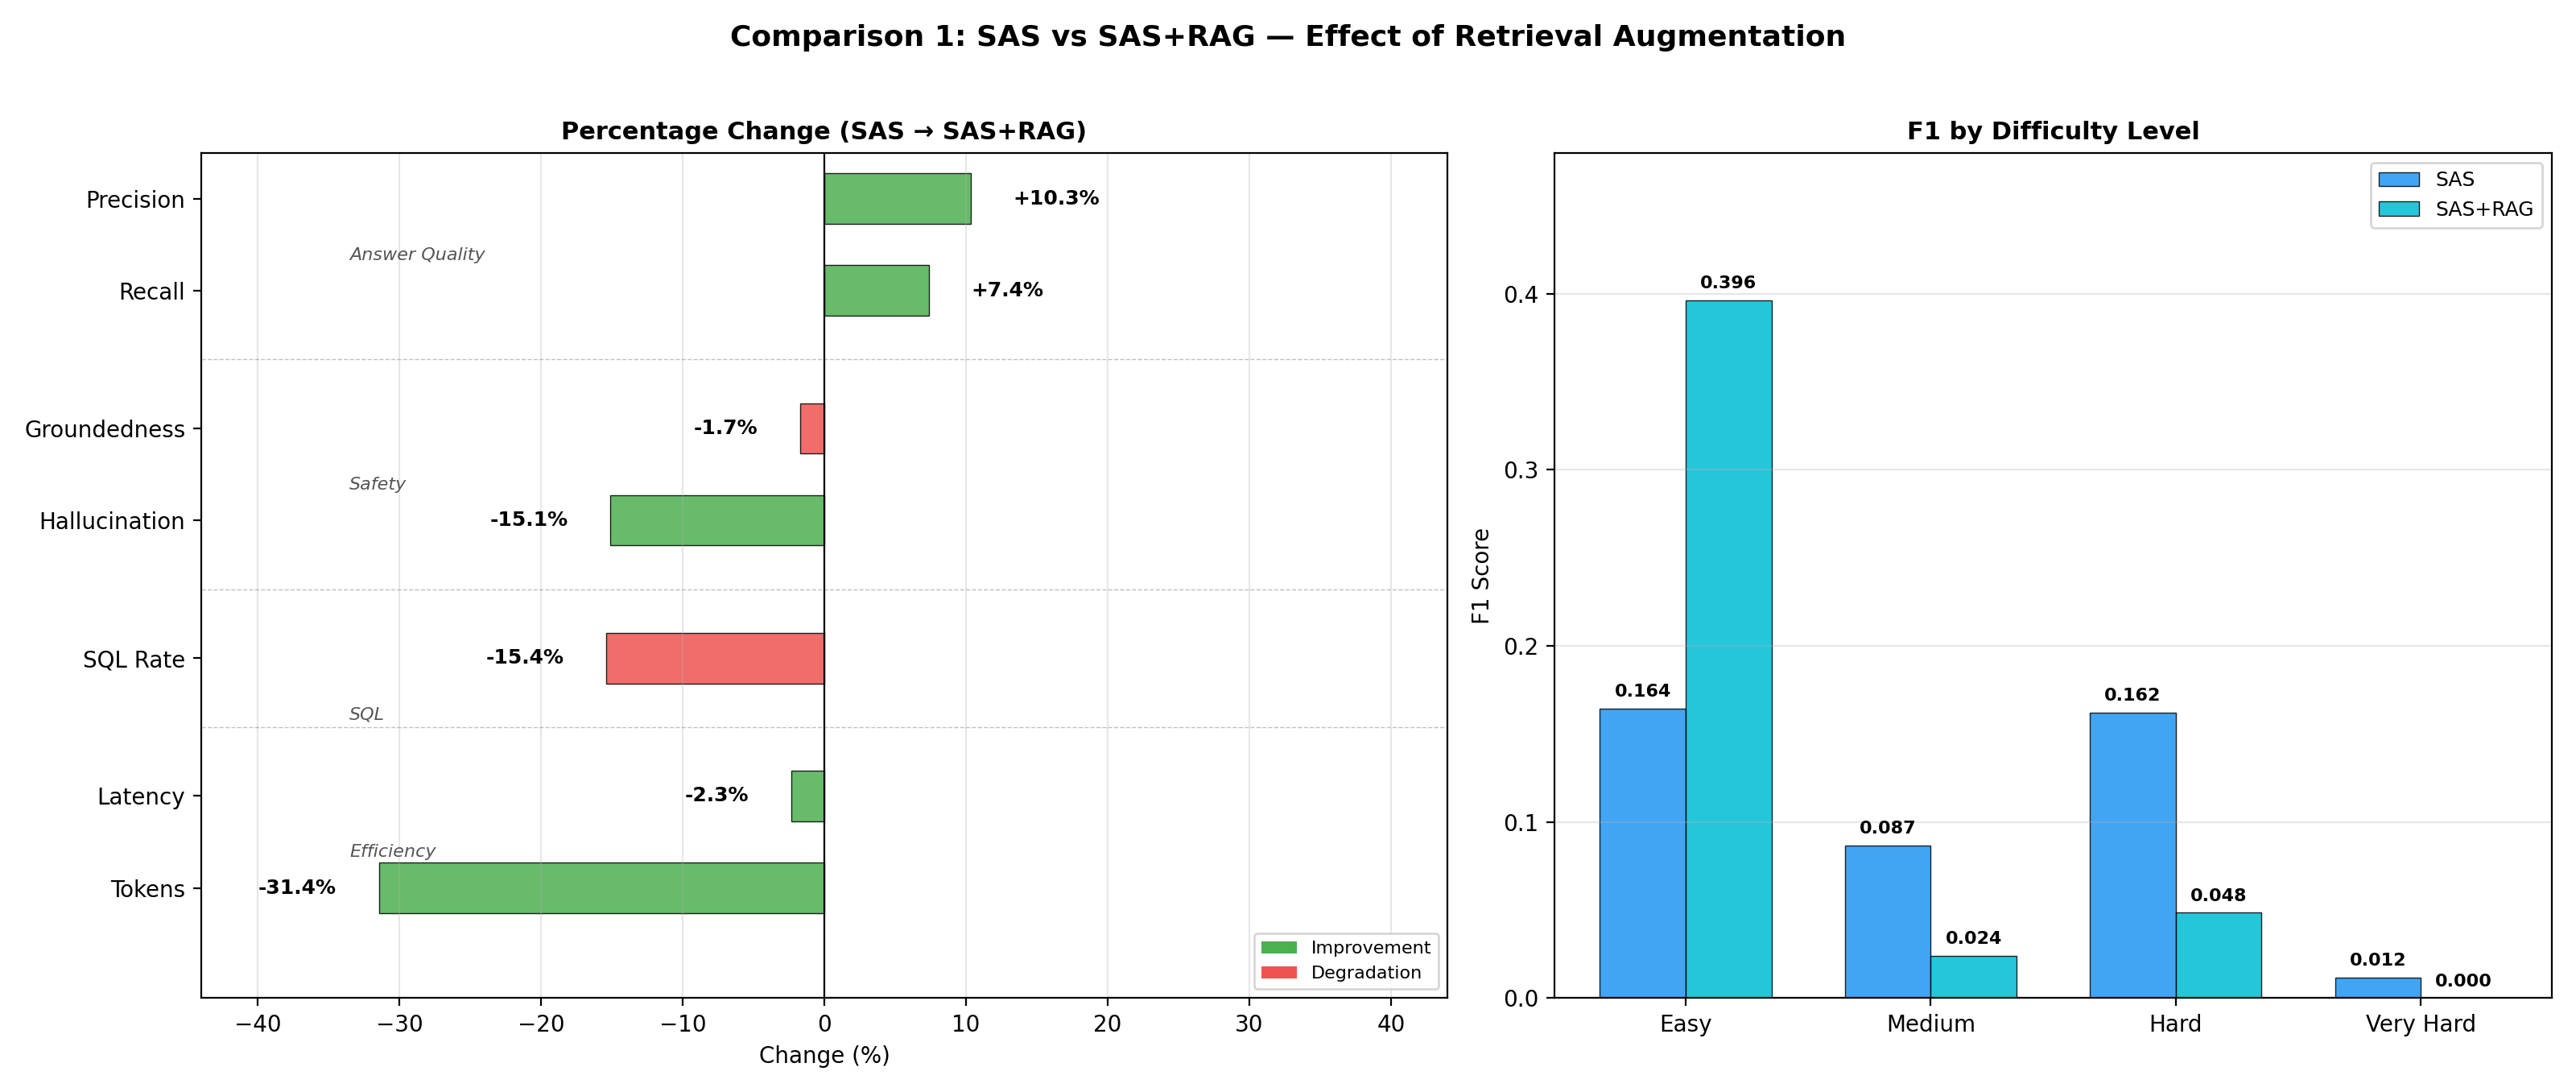

✓ Saved: /Workspace/Users/dquaglio@relias.com/MT/data/thesis_figures/comp1_sas_vs_sas_rag.pdf


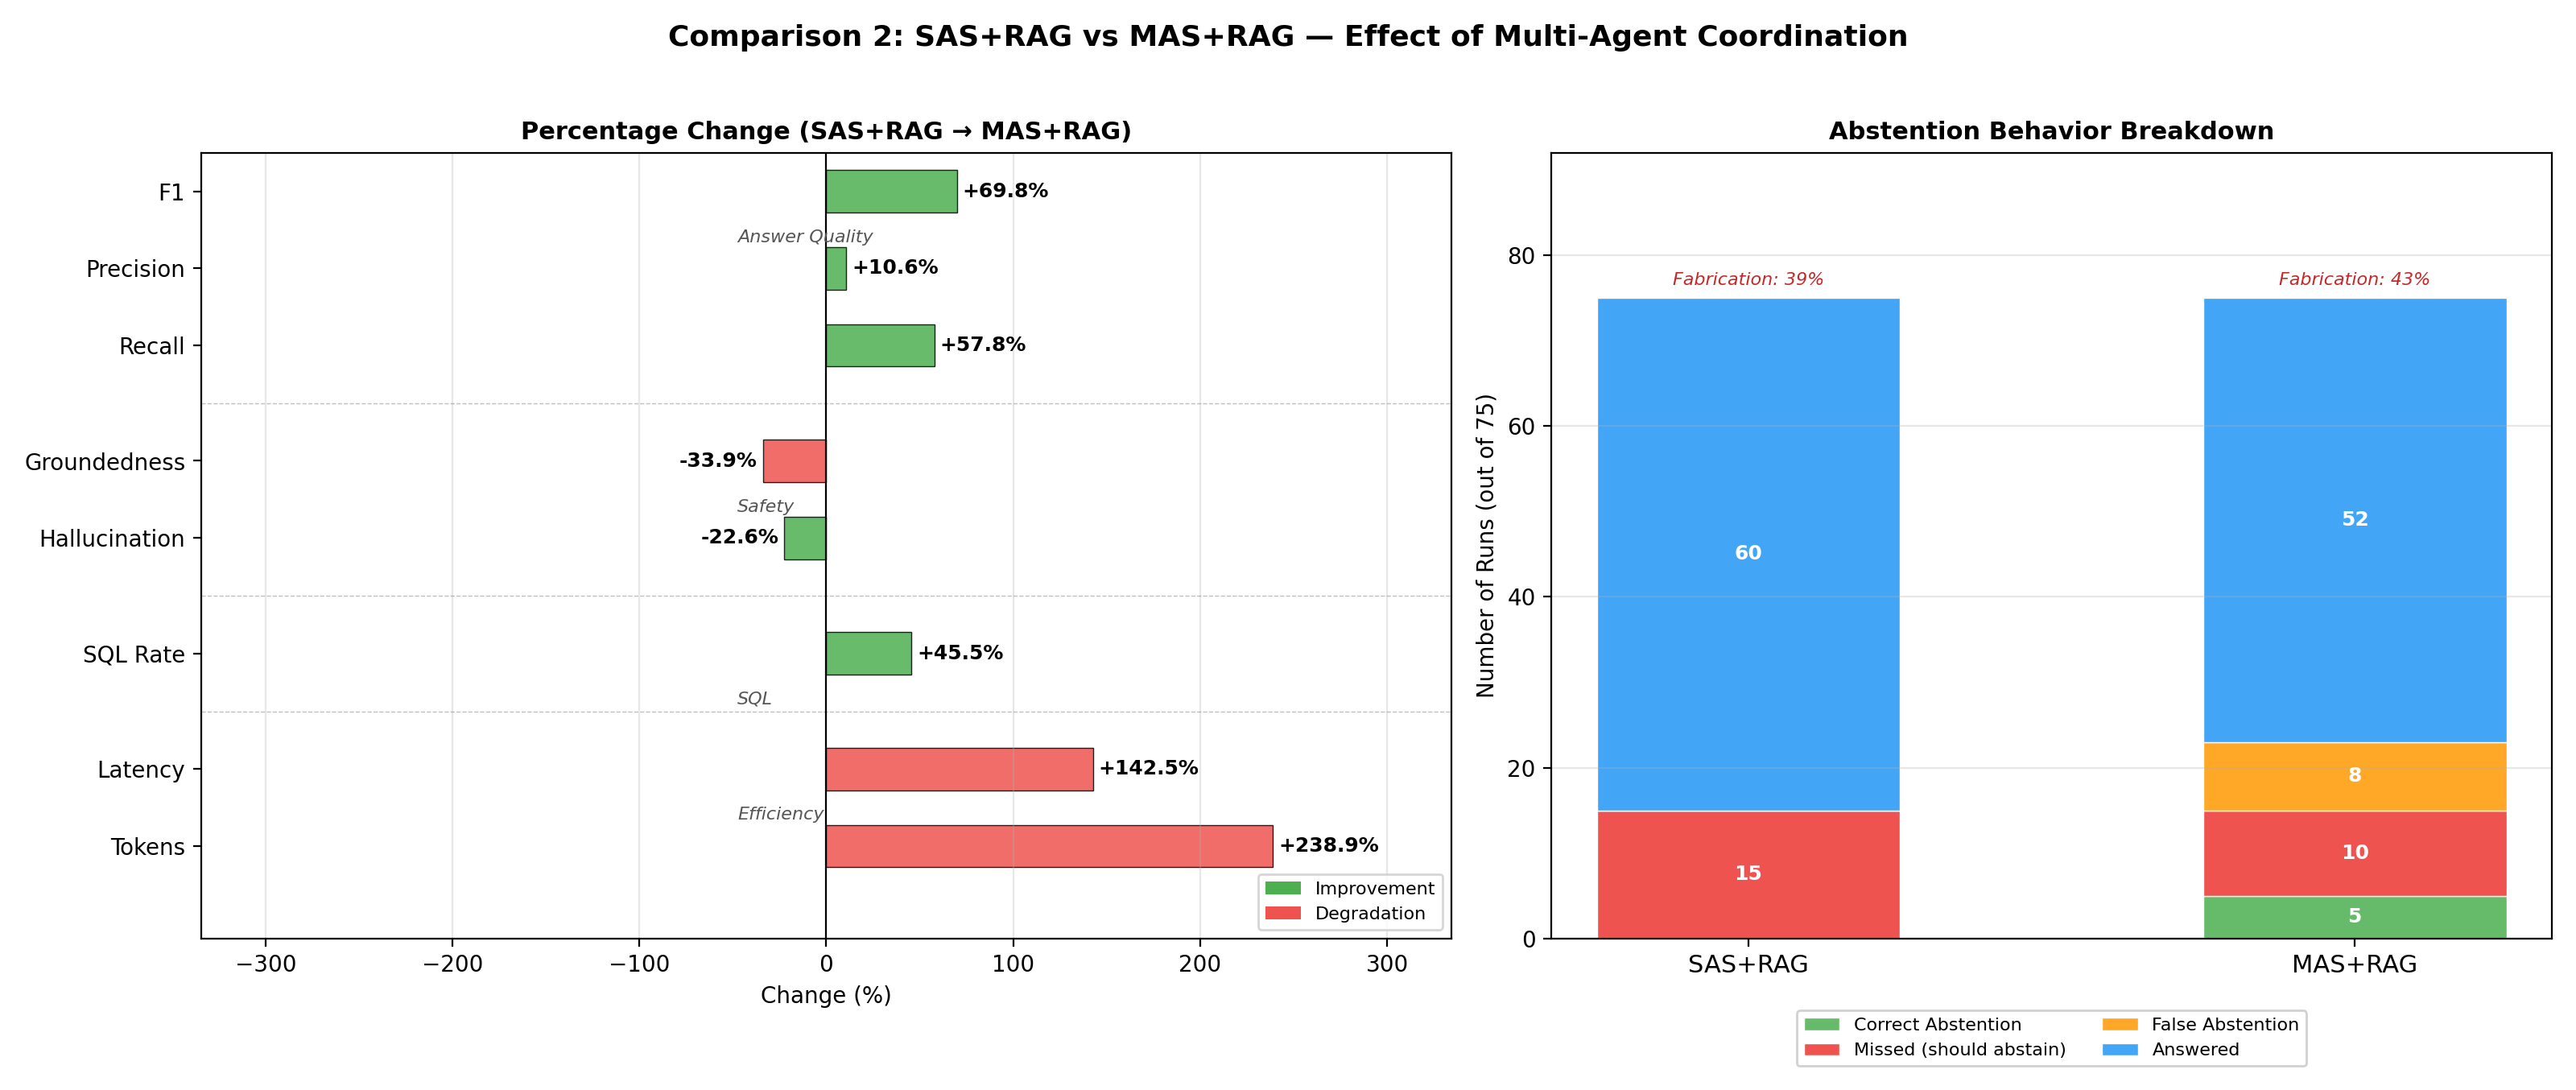

✓ Saved: /Workspace/Users/dquaglio@relias.com/MT/data/thesis_figures/comp2_sas_rag_vs_mas_rag.pdf


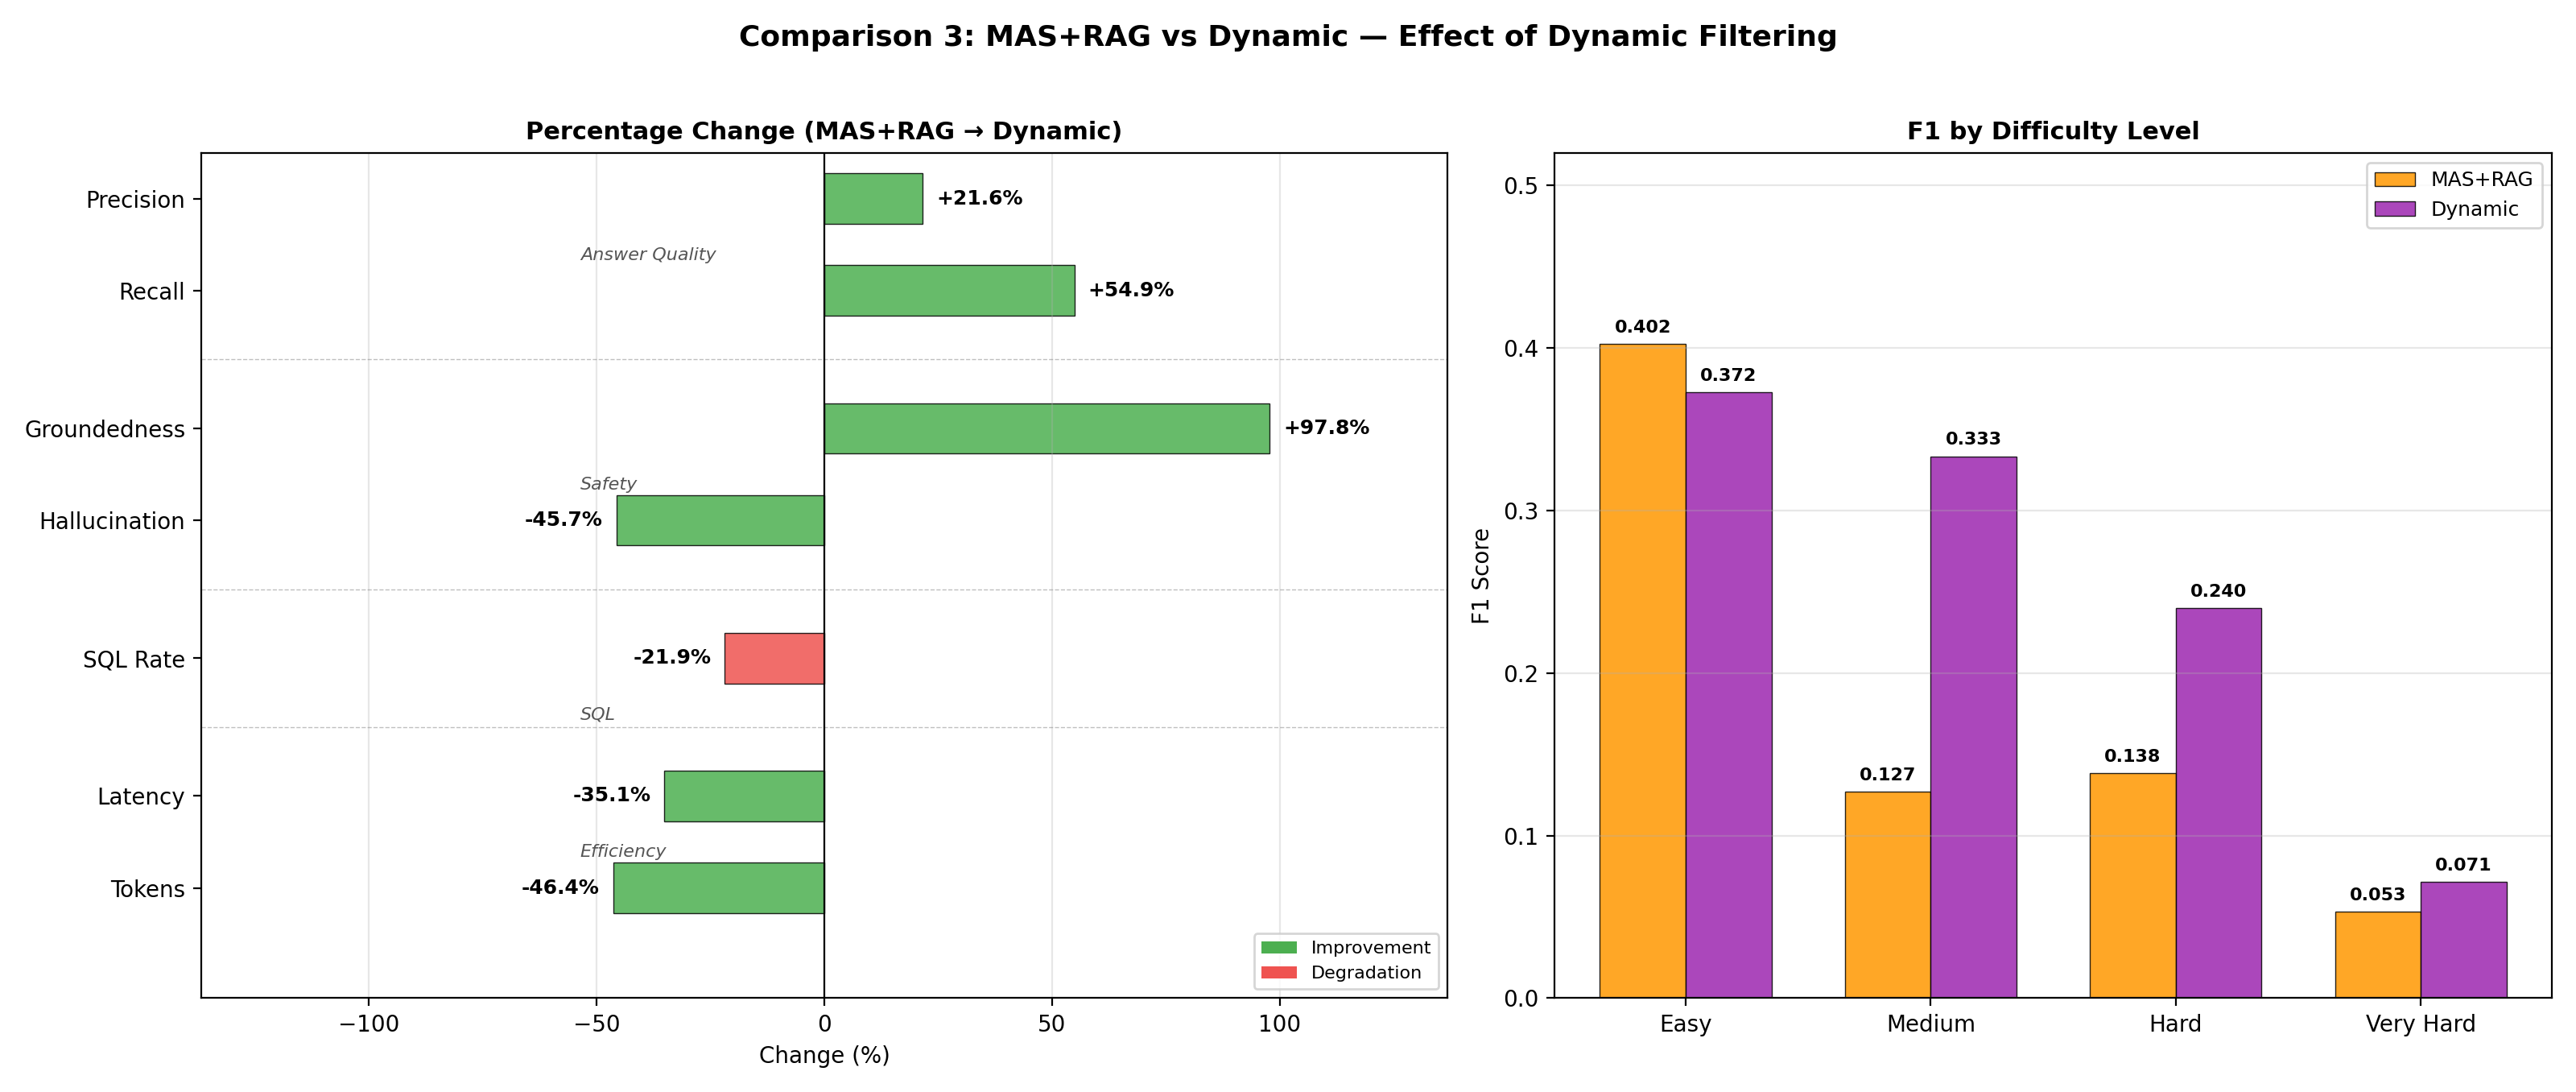

✓ Saved: /Workspace/Users/dquaglio@relias.com/MT/data/thesis_figures/comp3_mas_rag_vs_dynamic.pdf


In [0]:
%run ../mt_thesis_pdf_figures